# Homework 2: Probability Models

BEE 4850/5850

**Name**: Fenya Bartram

**ID**: fdb34

> **Due Date**
>
> Friday, 2/21/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to fit a sea-level rise model using normal
    residuals and to assess the validity of that assumption.
-   Problem 2 asks you to model the time series of hourly
    weather-related variability at a tide gauge using an autoregressive
    model.
-   Problem 3 asks you to use Poisson regression to predict salamander
    counts based on environmental data.
-   Problem 4 (only required for students in BEE 5850) asks you to look
    at the impact of the gender of hurricane names on deaths[1].

[1] Yes, seriously. Ish. Trust me, I know.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [ ]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [ ]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization tools

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np  
import scipy
from scipy.stats import norm
from scipy.stats import pearsonr
from scipy.optimize import minimize
import math
from scipy.optimize import Bounds
from scipy.stats import poisson

## Problems

### Scoring

-   Problem 1 is worth 7 points.
-   Problem 2 is worth 6 points.
-   Problem 3 is worth 7 points.
-   Problem 4 is worth 5 points.

### Problem 1

Consider the following sea-level rise model from [Grinsted et al
(2010)](https://doi.org/10.1007/s00382-008-0507-2), which models
sea-level rise based on a linear relationship between global mean
temperature and an “equilibrium” sea level:

$$\begin{align*}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{align*}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$C (in mm).

**In this problem**:

-   Load the data from the `data/` folder and, following Grinsted et al
    (2010), normalize both datasets to the 1980-1999 mean (subtract that
    mean from the data).
    -   Global mean temperature data from the HadCRUT 5.0.2.0 dataset
        (<https://hadobs.metoffice.gov.uk/hadcrut5/data/HadCRUT.5.0.2.0/download.html>)
        can be found in
        `data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv`.
        This data is averaged over the Northern and Southern Hemispheres
        and over the whole year.
    -   Global mean sea level anomalies (relative to the 1990 mean
        global sea level) are in `data/CSIRO_Recons_gmsl_yr_2015.csv`,
        courtesy of CSIRO
        (<https://www.cmar.csiro.au/sealevel/sl_data_cmar.html>). The
        standard deviation of the estimate is also added for each year.
-   Write a function to simulate global mean sea levels under a set of
    model parameters after discretizing the equations above with a
    timestep of $\delta t = 1$ yr. You will need to subset the
    temperature data to the years where you also have sea-level data.
-   Fit the model under the assumption of Gaussian i.i.d. residuals
    (include both an uncertain model error term and the standard
    deviation of the observations in the probability model
    specification) by maximizing the likelihood. Report the parameter
    estimates. Note that you will need another parameter $S_0$ for the
    initial sea level. What can you conclude about the relationship
    between global mean temperature increases and global mean sea level
    rise rates?
-   How appropriate was the Gaussian i.i.d. probability model for the
    residuals? Use any needed quantitative or qualitative assessments of
    goodness of fit to justify your answer. If this was not an
    appropriate probability model, what would you change?

In [2]:
data_dir = os.path.join("data", "HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv")
gmt_data = pd.read_csv(data_dir, index_col = 'Time')

In [3]:
gmt_data['Anomaly (deg C)'] = gmt_data['Anomaly (deg C)'] - gmt_data.loc[1980:1999,:]['Anomaly (deg C)'].mean()

In [5]:
gmt_data.loc[1980:1999,:]['Anomaly (deg C)'].mean()

np.float64(-2.6367796834847467e-17)

In [6]:
data_dir = os.path.join("data", "CSIRO_Recons_gmsl_yr_2015.csv")
gmsa_data = pd.read_csv(data_dir, index_col = 'Time')
# gmsa_data = pd.read_csv(data_dir)
gmsa_data.index = gmsa_data.index-0.5

In [7]:
gmsa_data['GMSL (mm)'] = gmsa_data['GMSL (mm)'] - gmsa_data.loc[1980:1999,:]['GMSL (mm)'].mean()
gmsa_data.loc[1980:1999,:]['GMSL (mm)'].mean()

np.float64(0.0)

In [8]:
gmt_data = gmt_data.drop(gmt_data.index.difference(gmsa_data.index))

In [9]:
len(gmt_data)

134

In [10]:
Seq = np.zeros(len(gmt_data))

In [ ]:
# tds_riverflow_loglik: function to compute the log-likelihood for the tds model
# θ: vector of model parameters (coefficients β₀ and β₁ and stdev σ)
# tds, flow: vectors of data
function tds_riverflow_loglik(θ, tds, flow)
    β₀, β₁, σ = θ # unpack parameter vector
    μ = β₀ .+ β₁ * log.(flow) # find mean
    ll = sum(logpdf.(Normal.(μ, σ), tds)) # compute log-likelihood
    return ll
end

lb = [0.0, -1000.0, 1.0]
ub = [1000.0, 1000.0, 100.0]
θ₀ = [500.0, 0.0, 50.0]
optim_out = Optim.optimize(θ -> -tds_riverflow_loglik(θ, tds.tds_mgL, tds.discharge_cms), lb, ub, θ₀)
θ_mle = round.(optim_out.minimizer; digits=0)
@show θ_mle;

In [21]:
S = np.zeros(len(gmt_data))
S[0] = 2

In [11]:
def sim_gmsl(S_0, gmta_data, response_time, a, b):
    Seq = np.zeros(len(gmta_data))
    S = np.zeros(len(gmta_data))
    S[0] = S_0
        
    for i in range(1,len(gmta_data)-1):
        Seq[i] = a*gmta_data.iloc[i] + b
        S[i+1] = S[i] + (Seq[i]-S[i])/response_time
    
    return(S)
        

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import pacf


# Q-Q plot
plt.figure(figsize=(6, 5))
qqplot(resids_homogauss, line='s')
plt.title("Normal Q-Q Plot")
plt.xlabel("Theoretical Values")
plt.ylabel("Empirical Values")
plt.show()

# Partial Autocorrelation
pacf_homogauss = pacf(resids_homogauss, nlags=5)

# Partial Autocorrelation Plot
plt.figure(figsize=(6, 5))
plt.stem(range(1, 6), pacf_homogauss[1:], markerfmt='o', basefmt=" ", use_line_collection=True)
plt.axhline(0, color='black', linestyle='--')
plt.ylabel("Partial Autocorrelation")
plt.xlabel("Time Lag")
plt.title("Partial Autocorrelation Plot")
plt.show()



In [ ]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import norm

def gaussian_iid_homosked(params, temp_dat, temp_err, m):
    S, γ, α, d, D, T₀, σ = params 
    ebm_sim = m((S, γ, α, d, D, T₀))
    ll = np.sum(norm.logpdf(ebm_sim, loc=temp_dat, scale=np.sqrt(σ**2 + temp_err**2)))
    return ll

lower = [1.0, 0.5, 0.0, 50.0, 200.0, temp_lo[0], 0.0]
upper = [5.0, 1.5, 2.0, 200.0, 1000.0, temp_hi[0], 10.0]
p0 = [3.0, 1.0, 1.0, 100.0, 800.0, temp_obs[0], 5.0]

result = minimize(lambda params: -gaussian_iid_homosked(params, temp_obs, temp_sd, ebm_wrap), p0, bounds=list(zip(lower, upper)))
θ_iid = result.x



In [ ]:
def tds_riverflow_loglik(θ, tds, flow):
    β₀, β₁, σ = θ  # unpack parameter vector
    μ = β₀ + β₁ * np.log(flow)  # find mean
    ll = np.sum(norm.logpdf(tds, loc=μ, scale=σ))  # compute log-likelihood
    return ll

In [ ]:
def gmsl_loglik(θ, gmsl_data, gmta_data, gmsl_error):
    S_0, response_time, a, b, σ  = θ  # unpack parameter vector
    y = sim_gmsl(S_0, gmta_data, response_time, a, b)
    ll = np.sum(norm.logpdf(gmsl_data, loc=y, scale=np.sqrt(σ^2+gmsl_error^2)))  # compute log-likelihood
    return ll

In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize


lb = [0.0, -1000.0, 1.0]
ub = [1000.0, 1000.0, 100.0]
θ₀ = [500.0, 0.0, 50.0]

optim_out = minimize(lambda θ: -tds_riverflow_loglik(θ, tds['tds_mgL'], tds['discharge_cms']), θ₀, bounds=list(zip(lb, ub)))
θ_mle = np.round(optim_out.x)

print(θ_mle)



In [12]:
sim_out = sim_gmsl(0, gmt_data['Anomaly (deg C)'], 1, 1, 1)

<Axes: >

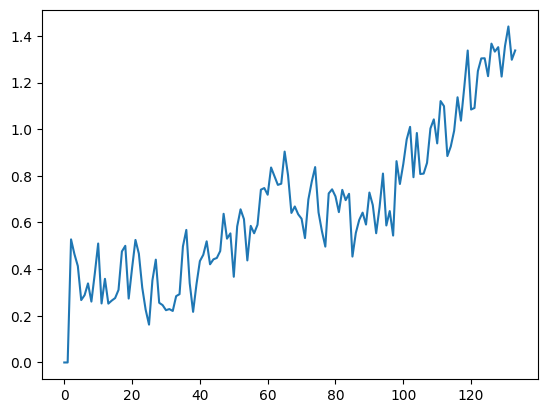

In [15]:
pd.Series(sim_out).plot()




<Axes: xlabel='Time'>

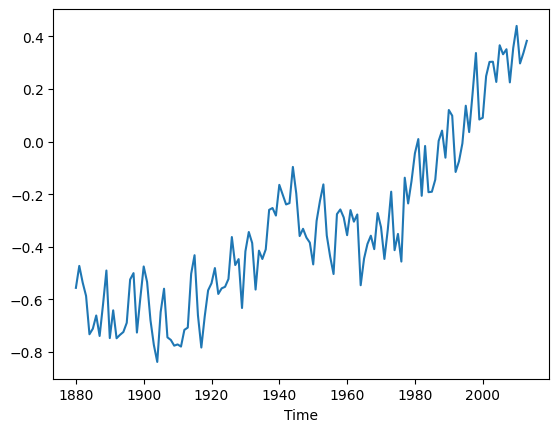

In [16]:
gmt_data['Anomaly (deg C)'].plot()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def ebm(rf_nonaerosol, rf_aerosol, p=(3.2, 1.0, 1.3, 100.0, 800.0, -0.1)):
    # set up model parameters
    S, γ, α, d, D, T0 = p  # this unpacks the parameter tuple into variables
    F2xCO2 = 4.0  # radiative forcing [W/m²] for a doubling of CO₂
    λ = F2xCO2 / S

    c = 4.184e6  # heat capacity/area [J/K/m²]
    C = c * d  # heat capacity of mixed layer (per area)
    CD = c * D  # heat capacity of deep layer (per area)
    F = rf_nonaerosol + α * rf_aerosol  # radiative forcing
    Δt = 31558152.0  # annual timestep [s]

    T = np.zeros_like(F)
    T[0] = T0
    TD = np.zeros_like(F)
    for i in range(len(F) - 1):
        T[i + 1] = T[i] + (F[i] - λ * T[i] - γ * (T[i] - TD[i])) / C * Δt
        TD[i + 1] = TD[i] + γ * (T[i] - TD[i]) / CD * Δt
    # return after normalizing to reference period
    return T

def ebm_wrap(params):
    return ebm(forcing_non_aerosol_85[hind_idx], forcing_aerosol_85[hind_idx], p=params)





In [ ]:
n_samples = 10_000
temp_iid = ebm_wrap(θ_iid)  # simulate IID best fit
# simulate projections with discrepancy and errors
temp_iid_proj = np.zeros((n_samples, len(temp_sd)))
for i in range(len(temp_sd)):
    temp_iid_err = np.random.normal(0, np.sqrt(θ_iid[-1]**2 + temp_sd[i]**2), n_samples)
    temp_iid_proj[:, i] = temp_iid[i] + temp_iid_err

# calculate quantiles
temp_iid_q = np.quantile(temp_iid_proj, [0.05, 0.5, 0.95], axis=0)

plt.scatter(time_obs, temp_obs, color='black', label="Observations")
plt.ylabel("(°C)")
plt.xlabel("Year")
plt.title("Temperature Anomaly")
plt.plot(time_obs, temp_iid_q[1, :], color='red', label="Gaussian Discrepancy")
plt.fill_between(time_obs, temp_iid_q[0, :], temp_iid_q[2, :], color='red', alpha=0.3)
plt.legend()
plt.gcf().set_size_inches(6, 5)
plt.show()

### Problem 2

Tide gauge data is complicated to analyze because it is influenced by
different harmonic processes (such as the linear cycle). In this
problem, we will develop a model for this data using [NOAA data from the
Sewell’s Point tide
gauge](https://tidesandcurrents.noaa.gov/waterlevels.html?id=8638610)
outside of Norfolk, VA from `data/norfolk-hourly-surge-2015.csv`. This
is hourly data (in m) from 2015 and includes both the observed data
(`Verified (m)`) and the tide level predicted by NOAA’s sinusoidal model
for periodic variability, such as tides and other seasonal cycles
(`Predicted (m)`).

**In this problem**:

-   Load the data file. Take the difference between the observations and
    the sinusoidal predictions to obtain the tide level which could be
    attributed to weather-related variability (since for one year
    sea-level rise and other factors are unlikely to matter). Plot this
    data.
-   Develop an autoregressive (AR) model for the weather-related
    variability in the Norfolk tide gauge. Make sure to include your
    logic or exploratory analysis used in determining the model
    specification.
-   Use your model to simulate 1,000 realizations of hourly tide gauge
    observations by adding simulations from your AR model back to the
    predicted sinusoidal trend. What is the distribution of the maximum
    tide level? How does this compare to the observed value?

In [5]:
data_dir = os.path.join("data", "norfolk-hourly-surge-2015.csv")
gauge_data = pd.read_csv(data_dir)

In [6]:
tide_variable = gauge_data['Verified (m)'] - gauge_data['Predicted (m)']

Text(0, 0.5, 'Tide level attributable to weather-related variability (m)')

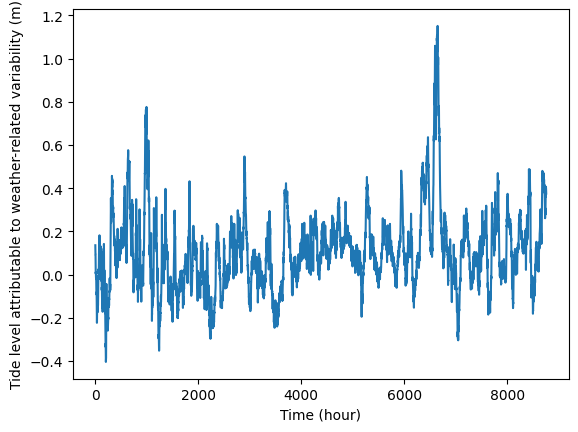

In [7]:
plt.plot(tide_variable)
plt.xlabel('Time (hour)')
plt.ylabel('Tide level attributable to weather-related variability (m)')


In [116]:
ar1_loglik_whitened(np.array([0.5, 1]), tide_variable)

np.float64(-8098.564439409143)

In [88]:
def rosen_with_args(x, a, b):
    """The Rosenbrock function with additional arguments"""
    return sum(a*(x[1:]-x[:-1]**2.0)**2.0 + (1-x[:-1])**2.0) + b

In [29]:
dat  = tide_variable

In [ ]:
bounds = Bounds([0, 1], [0, 10000000000])
x0 = np.array([0.5,10000])
res = minimize(-ar1_loglik_whitened, x0, bounds=bounds)

In [ ]:
import numpy as np
from scipy.optimize import minimize

lb = [-0.99, 0.01]
ub = [0.99, 5]
init = [0.6, 0.3]

def ar1_loglik_whitened(theta, dat):
    # might need to include mean or trend parameters as well
    # subtract trend from data to make this mean-zero in this case
    rho, sigma = theta
    T = len(dat)
    ll = 0  # initialize log-likelihood counter
    for i in range(T):
        if i == 0:
            ll += norm.logpdf(dat[i], loc=0, scale=np.sqrt(sigma**2 / (1 - rho**2)))
        else:
            ll += norm.logpdf(dat[i], loc=rho * dat[i-1], scale=sigma)
    return ll

# Define the functions ar1_loglik_whitened and ar1_loglik_joint as needed
# For example:
# def ar1_loglik_whitened(theta, ts_sim):
#     # Implementation here
#     pass

# def ar1_loglik_joint(theta, ts_sim):
#     # Implementation here
#     pass

optim_whitened = minimize(lambda θ: -ar1_loglik_whitened(θ, ts_sim), init, bounds=list(zip(lb, ub)))
θ_wn_mle = np.round(optim_whitened.x, 2)
print("θ_wn_mle:", θ_wn_mle)


In [32]:
res

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 8240.504207372895
        x: [ 0.000e+00  1.000e+00]
      nit: 2
      jac: [       nan  8.379e+03]
     nfev: 20
     njev: 10
 hess_inv: None

In [ ]:
# import numpy as np
# from scipy.stats import multivariate_normal

# def ar1_loglik_joint(theta, dat):
#     # might need to include mean or trend parameters as well
#     # subtract trend from data to make this mean-zero in this case
#     rho, sigma = theta
#     T = len(dat)
#     # compute all of the pairwise lags
#     H = np.abs(np.arange(1, T + 1)[:, None] - np.arange(1, T + 1))
#     P = rho ** H  # exponentiate ρ by each lag
#     Sigma = (sigma ** 2) / (1 - rho ** 2) * P
#     ll = multivariate_normal.logpdf(dat, mean=np.zeros(T), cov=Sigma)
#     return ll



In [ ]:
# def ar1_loglik_whitened(θ):
#     # might need to include mean or trend parameters as well
#     # subtract trend from data to make this mean-zero in this case
#     ρ = θ[0]
#     σ = θ[1]
#     T = len(dat)
#     ll = 0 # initialize log-likelihood counter
#     for i in range(1,T):
#         if i == 1:
#             ll += norm.logpdf(dat[i], 0, math.sqrt(σ**2 / (1 - ρ**2)))
#         else:
#             ll +=norm.logpdf(dat[i], ρ * dat[i-1], σ)
#     return -ll


In [183]:
res.x

array([0., 1.])

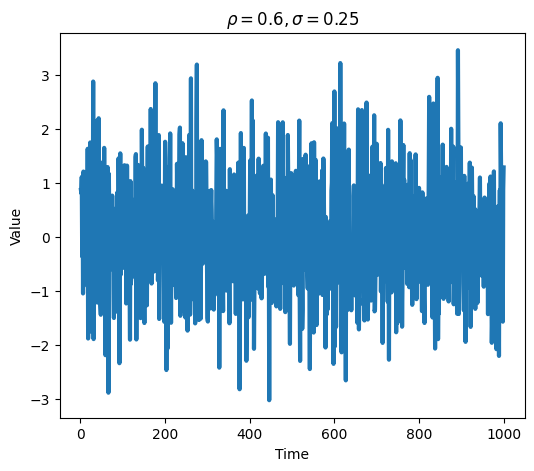

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# rho = 0.6
# sigma = 0.25
rho = res.x[0]
sigma = res.x[1]
T = 1000
ts_sim = np.zeros(T)



# simulate synthetic AR(1) series
for t in range(T):
    if t == 0:
        ts_sim[t] = np.random.normal(0, np.sqrt(sigma**2 / (1 - rho**2)))
    else:
        ts_sim[t] = np.random.normal(rho * ts_sim[t-1], sigma)

plt.figure(figsize=(6, 5))
plt.plot(np.arange(1, T+1), ts_sim, linewidth=3)
plt.xlabel("Time")
plt.ylabel("Value")
plt.title(r"$\rho = 0.6, \sigma = 0.25$")
plt.show()

In [159]:
res

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -124631.70188334596
        x: [ 0.000e+00  6.022e+05]
      nit: 9
      jac: [       nan  0.000e+00]
     nfev: 34
     njev: 17
 hess_inv: None

In [ ]:
x0 = np.array([1.3, 0.7, 0.8, 1.9, 1.2])
res = minimize(rosen_with_args, x0, method='nelder-mead',
               args=(0.5, 1.), options={'xatol': 1e-8, 'disp': True})


ImportError: cannot import name 'maximize' from 'scipy' (C:\Users\fenya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\__init__.py)

In [130]:
res

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 8239.57602083969
        x: [ 0.000e+00  1.000e+00]
      nit: 0
      jac: [       nan  8.378e+03]
     nfev: 2
     njev: 1
 hess_inv: None

In [ ]:
import numpy as np
from scipy.optimize import maximize

lb = [0.0, -1000.0, 1.0]
ub = [1000.0, 1000.0, 100.0]
θ₀ = [500.0, 0.0, 50.0]

optim_out = maximize(objective, θ₀, bounds=list(zip(lb, ub)))
θ_mle = np.round(optim_out.x).astype(int)


SyntaxError: invalid character '₀' (U+2080) (904817003.py, line 6)

In [ ]:

# def ar1_loglik_joint(ρ, σ, dat):
#     # might need to include mean or trend parameters as well
#     # subtract trend from data to make this mean-zero in this case
#     T = len(dat)
#     # compute all of the pairwise lags
#     # this is an "outer product"; syntax will differ wildly by language
#     H = abs.((1:T) .- (1:T)')
#     P = ρ.**H # exponentiate ρ by each lag
#     Σ = σ**2 / (1 - ρ**2) * P
#     ll = logpdf(MvNormal(zeros(T), Σ), dat)
#     return ll


## Problem 3

The file `data/salamanders.csv` contains counts of salamanders from 47
different plots of the same area in California, as well as the
percentage of ground cover and age of the forest in the plot. You would
like to see if you can use these data to predict the salamander counts
with a Poisson regression.

**In this problem**:

-   Load the data. You may need to standardize the predictors as they
    are much larger than the counts.
-   Fit a Poisson regression model for salamander counts using the
    percentage of ground cover.
-   Plot the expected counts and 90% prediction intervals from your
    model. How well does the model predict the observed counts? In what
    ways does it do a good or bad job?
-   Can you improve the model by including forest age? Why do you think
    this helps or does not help with prediction?

In [36]:
data_dir = os.path.join("data", "salamanders.csv")
salamander_data = pd.read_csv(data_dir, index_col='SITE')

In [44]:
col = 'PCTCOVER'
salamander_data[col] = (salamander_data[col] - salamander_data[col].mean())/salamander_data[col].std()

col = 'FORESTAGE'
salamander_data[col] = (salamander_data[col] - salamander_data[col].mean())/salamander_data[col].std()

In [51]:
def salaman_model(params, pctcover, salaman_data):
    β_0, β_1 = params
    λ = np.exp(β_0 + β_1 * pctcover)
    loglik = np.sum(poisson.logpmf(salaman_data, λ))
    return loglik

In [53]:
lb = [-100.0, -100.0]
ub = [100.0, 100.0]
init = [0.0, 0.0]

result = minimize(lambda θ: -salaman_model(θ, salamander_data['PCTCOVER'], salamander_data['SALAMAN']), init, bounds=list(zip(lb, ub)))
θ_mle = result.x
print(np.round(θ_mle, decimals=5))

[0.42951 1.15951]


In [66]:
θ_mle[1]

np.float64(1.1595053810010183)

In [68]:
salamander_data['PCTCOVER'].min()

np.float64(-1.6485197313672117)

In [76]:
x = np.arange(salamander_data['PCTCOVER'].min(), salamander_data['PCTCOVER'].max(),0.01)

In [77]:
β_0 = θ_mle[0]
β_1 = θ_mle[1]
λ = np.exp(β_0 + β_1 * x)

In [ ]:
plt.plot(time_obs, temp_iid_q[1, :], color='red', label="Gaussian Discrepancy")
plt.fill_between(time_obs, temp_iid_q[0, :], temp_iid_q[2, :], color='red', alpha=0.3)

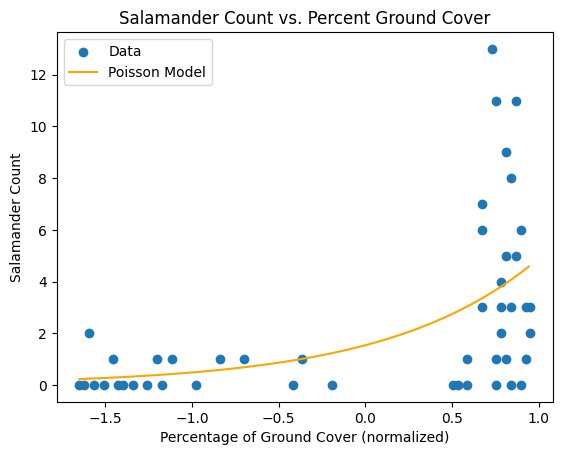

In [81]:
plt.scatter(salamander_data['PCTCOVER'], salamander_data['SALAMAN'])
plt.plot(x, λ, color = 'orange')
plt.ylabel("Salamander Count")
plt.xlabel("Percentage of Ground Cover (normalized)")
plt.title("Salamander Count vs. Percent Ground Cover")
plt.legend(['Data','Poisson Model'])

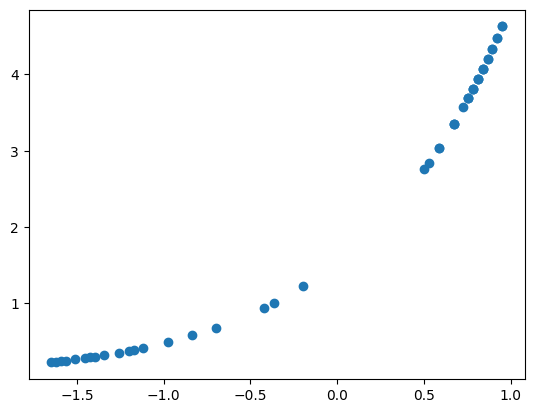

In [70]:
plt.scatter(salamander_data['PCTCOVER'], λ)

### Problem 4

<span style="color:red;">GRADED FOR 5850 STUDENTS ONLY</span>

In 2014, [a paper was published in a prestigious
journal](https://www.pnas.org/doi/10.1073/pnas.1402786111) which claimed
that hurricanes with more feminine names are deadlier than hurricanes
with more masculine names because people take warnings about
female-named hurricanes less seriously[1]. The file
`data/Hurricanes.csv` contains the original data used in this analysis.
While we won’t replicate the specific analysis in this paper, let’s use
the data to look at this hypothesis.

**In this problem**:

-   One might interpret the hypothesis to claim that the impact of the
    name is strengthened by the the more powerful. A measure of
    hurricane strength is its minimum pressure (`min_pressure` in the
    dataset). Fit a model that predicts deaths (‘deaths’) using the
    femininity of the name (`femininity`) and minimum pressure (you may
    need to standardize the pressure).
-   Interpret the results by generating counterfactual simulations for
    hurricanes with the most feminine and masculine name scores. Plot
    the expected values and 90% prediction intervals from these two sets
    of simulations and compare with the observed storm deaths. Where
    does the model do well or not well? Does the effect size of the
    gender of the name seem plausible?
-   Conclude with a summary of your conclusions about the impact of the
    gender of a hurricane’s name on deaths. How might you change the
    approach in this problem to keep exploring this hypothesis, if at
    all?

[1] This paper has become a bit of a joke among statisticians, but let’s
take the hypothesis seriously for this problem’s sake.

In [85]:
data_dir = os.path.join("data", "Hurricanes.csv")
hurricane_data = pd.read_csv(data_dir)

In [86]:
hurricane_data

,name,year,deaths,category,min_pressure,damage_norm,female,femininity
0,Easy,1950,2,3,960,1590,1,6.77778
1,King,1950,4,3,955,5350,0,1.38889
2,Able,1952,3,1,985,150,0,3.83333
3,Barbara,1953,1,1,987,58,1,9.83333
4,Florence,1953,0,1,985,15,1,8.33333
...,...,...,...,...,...,...,...,...
87,Gustav,2008,52,2,954,4360,0,1.72222
88,Ike,2008,84,2,950,20370,0,1.88889
89,Irene,2011,41,1,952,7110,1,9.27778
90,Isaac,2012,5,1,966,24000,0,1.94444


## References

https://www.codeconvert.ai/julia-to-python-converter